# Ngày 3 — Tune Hyperparameter, Đánh giá & Threshold Tuning

Notebook này thực hiện đúng task của **Ngày 3**: tune sâu 2 ứng viên tốt nhất từ Ngày 2
(Logistic Regression, CatBoost) bằng `RandomizedSearchCV`, đánh giá đầy đủ trên tập test,
chọn mô hình cuối cùng, và tối ưu ngưỡng quyết định (threshold) theo bài toán kinh doanh.

> Tiếp tục dùng `imblearn.Pipeline` (SMOTE bên trong mỗi fold) — đúng nguyên tắc đã
> rút ra ở Ngày 2, để tránh lặp lại lỗi rò rỉ dữ liệu trong lúc tune.


In [1]:
import os
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, precision_recall_curve, roc_curve)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'


## 1. Tái tạo đúng tập Train/Test của Ngày 2

Dùng lại `scaler.pkl` đã lưu (chỉ `.transform()`, không fit lại) và cùng `random_state=42`
để tái tạo **chính xác** cùng một phép chia train/test — rồi đối chiếu với `X_test_scaled.csv`
đã lưu ở Ngày 2 để chắc chắn không có gì lệch.

In [2]:
df = pd.read_csv("../data/processed/attrition_encoded.csv")
X = df.drop(columns=['Attrition'])
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = joblib.load("../models/scaler.pkl")
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Đối chiếu với file đã lưu ở Ngày 2 để chắc chắn tái tạo đúng
X_test_saved = pd.read_csv("../data/processed/X_test_scaled.csv")
y_test_saved = pd.read_csv("../data/processed/y_test.csv").squeeze()
assert np.allclose(X_test_scaled.values.astype(float), X_test_saved.values.astype(float)), "Lệch dữ liệu test!"
assert (y_test.values == y_test_saved.values).all(), "Lệch nhãn test!"
print("✅ Đã tái tạo đúng khớp 100% với dữ liệu đã lưu ở Ngày 2.")
print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


✅ Đã tái tạo đúng khớp 100% với dữ liệu đã lưu ở Ngày 2.
Train: (1176, 44), Test: (294, 44)


## 2. Tune sâu bằng RandomizedSearchCV (Pipeline: SMOTE + Model)

Dùng dữ liệu train **gốc chưa SMOTE** (`X_train_scaled`, `y_train`) — SMOTE nằm trong
pipeline nên sẽ tự chạy lại đúng chuẩn bên trong từng fold của CV.
Tiêu chí tune (`scoring`) là **PR-AUC** (`average_precision`) — phản ánh chất lượng mô
hình trên mọi ngưỡng, tách biệt với bước chọn ngưỡng cụ thể sẽ làm riêng ở phần 5.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Logistic Regression ---
pipe_lr = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', LogisticRegression(max_iter=2000, random_state=42)),
])
param_dist_lr = {
    'clf__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear'],
}
search_lr = RandomizedSearchCV(
    pipe_lr, param_distributions=param_dist_lr, n_iter=12,
    scoring='average_precision', cv=cv, random_state=42, n_jobs=-1,
)
search_lr.fit(X_train_scaled, y_train)
print("Logistic Regression — best PR-AUC (CV):", round(search_lr.best_score_, 4))
print("Best params:", search_lr.best_params_)


Logistic Regression — best PR-AUC (CV): 0.6146
Best params: {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 0.01}


In [4]:
# --- CatBoost ---
pipe_cb = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=5)),
    ('clf', CatBoostClassifier(random_state=42, verbose=False, allow_writing_files=False)),
])
param_dist_cb = {
    'clf__iterations': [200, 400, 600],
    'clf__depth': [4, 6, 8],
    'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'clf__l2_leaf_reg': [1, 3, 5, 7],
}
search_cb = RandomizedSearchCV(
    pipe_cb, param_distributions=param_dist_cb, n_iter=15,
    scoring='average_precision', cv=cv, random_state=42, n_jobs=-1,
)
search_cb.fit(X_train_scaled, y_train)
print("CatBoost — best PR-AUC (CV):", round(search_cb.best_score_, 4))
print("Best params:", search_cb.best_params_)


CatBoost — best PR-AUC (CV): 0.6241
Best params: {'clf__learning_rate': 0.03, 'clf__l2_leaf_reg': 1, 'clf__iterations': 400, 'clf__depth': 6}


## 3. Đánh giá đầy đủ trên tập Test (chưa từng bị đụng tới)

`search.best_estimator_` đã được refit tự động trên toàn bộ `X_train_scaled` với bộ
tham số tốt nhất — gọi thẳng `.predict_proba()` trên test là an toàn (bước SMOTE trong
pipeline chỉ chạy lúc `.fit()`, tự động bỏ qua lúc `.predict()`).

In [5]:
candidates = {
    "Logistic Regression (tuned)": search_lr.best_estimator_,
    "CatBoost (tuned)": search_cb.best_estimator_,
}

eval_rows = {}
proba_dict = {}
for name, model in candidates.items():
    proba = model.predict_proba(X_test_scaled)[:, 1]
    pred = model.predict(X_test_scaled)
    proba_dict[name] = proba

    eval_rows[name] = {
        'Precision': classification_report(y_test, pred, output_dict=True)['1']['precision'],
        'Recall': classification_report(y_test, pred, output_dict=True)['1']['recall'],
        'F1': classification_report(y_test, pred, output_dict=True)['1']['f1-score'],
        'PR-AUC': average_precision_score(y_test, proba),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }
    print(f"=== {name} (ngưỡng mặc định 0.5) ===")
    print(classification_report(y_test, pred, target_names=['No', 'Yes']))

eval_df = pd.DataFrame(eval_rows).T.round(4)
eval_df


=== Logistic Regression (tuned) (ngưỡng mặc định 0.5) ===
              precision    recall  f1-score   support

          No       0.93      0.77      0.84       247
         Yes       0.36      0.68      0.47        47

    accuracy                           0.75       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.84      0.75      0.78       294

=== CatBoost (tuned) (ngưỡng mặc định 0.5) ===
              precision    recall  f1-score   support

          No       0.88      0.98      0.93       247
         Yes       0.78      0.30      0.43        47

    accuracy                           0.87       294
   macro avg       0.83      0.64      0.68       294
weighted avg       0.86      0.87      0.85       294



,Precision,Recall,F1,PR-AUC,ROC-AUC
Logistic Regression (tuned),0.3556,0.6809,0.4672,0.568,0.7856
CatBoost (tuned),0.7778,0.2979,0.4308,0.572,0.8012


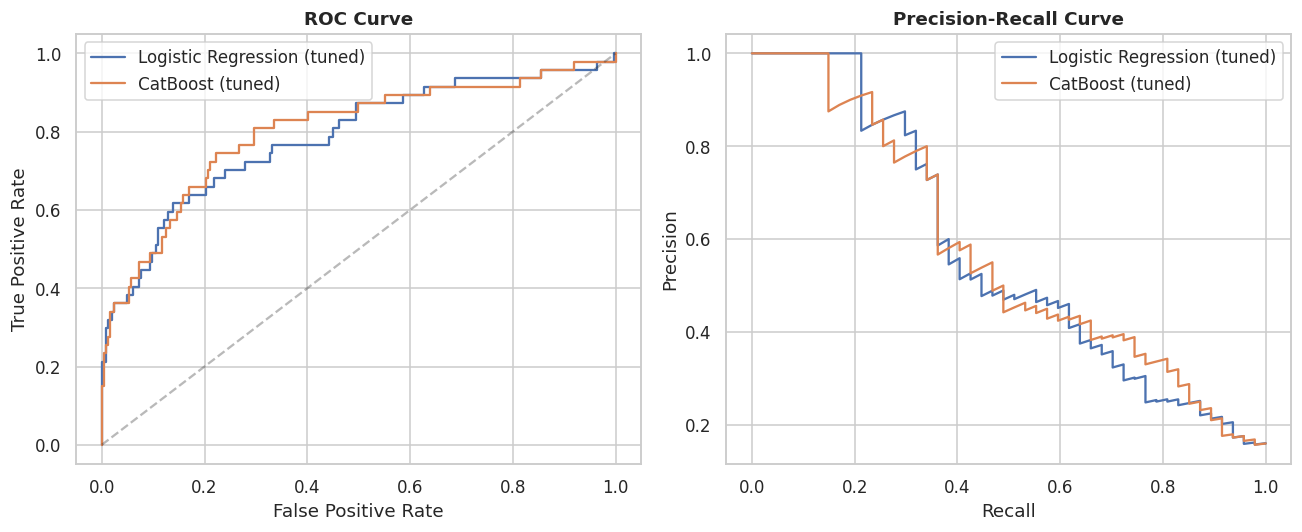

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for name, proba in proba_dict.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=name)
    axes[1].plot(rec, prec, label=name)

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_title("ROC Curve"); axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[1].set_title("Precision-Recall Curve"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.savefig("../images/07_roc_pr_curves.png", bbox_inches='tight')
plt.show()


## 4. Chọn mô hình cuối cùng

In [7]:
# Chọn theo PR-AUC trước (thước đo ổn định nhất với dữ liệu mất cân bằng), Recall làm tiêu chí phụ
winner_name = eval_df.sort_values(['PR-AUC', 'Recall'], ascending=False).index[0]
final_model = candidates[winner_name]
final_proba = proba_dict[winner_name]

print(f"🏆 Mô hình được chọn: {winner_name}")
print(eval_df.loc[[winner_name]])


🏆 Mô hình được chọn: CatBoost (tuned)
                  Precision  Recall      F1  PR-AUC  ROC-AUC
CatBoost (tuned)     0.7778  0.2979  0.4308   0.572   0.8012


## 5. Threshold Tuning

Nhắc lại quyết định kinh doanh từ Ngày 1: bỏ sót một người sắp nghỉ (False Negative) tốn
kém hơn nhiều so với báo động nhầm (False Positive) → ưu tiên **Recall ≥ 0.80** thay vì
giữ ngưỡng mặc định 0.5.

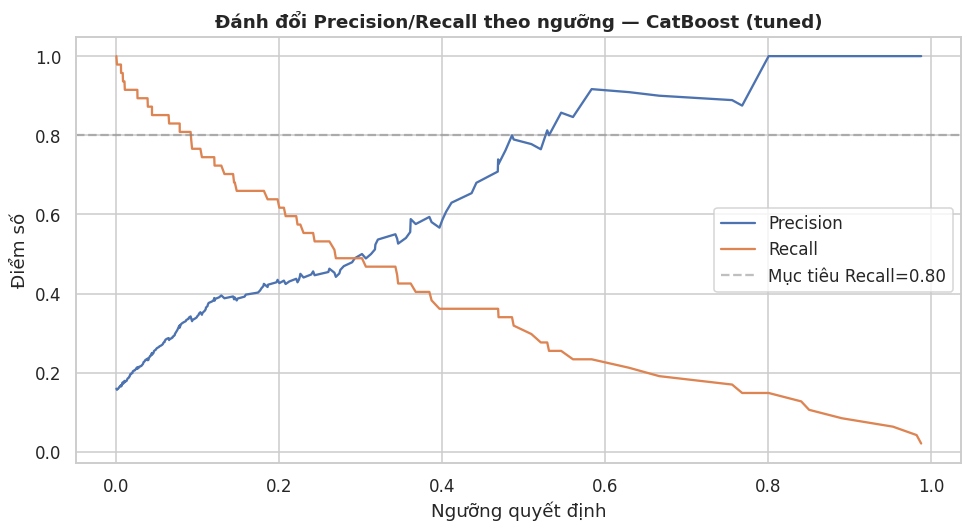

Ngưỡng đề xuất: 0.001  |  Recall: 1.000  |  Precision: 0.160
Ngưỡng 0.30 -> Recall=0.489, Precision=0.500
Ngưỡng 0.35 -> Recall=0.426, Precision=0.541
Ngưỡng 0.40 -> Recall=0.362, Precision=0.586
Ngưỡng 0.45 -> Recall=0.362, Precision=0.708
Ngưỡng 0.50 -> Recall=0.298, Precision=0.778


In [8]:
precisions, recalls, thresholds = precision_recall_curve(y_test, final_proba)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, precisions[:-1], label='Precision')
ax.plot(thresholds, recalls[:-1], label='Recall')
ax.axhline(0.80, color='gray', linestyle='--', alpha=0.5, label='Mục tiêu Recall=0.80')
ax.set_xlabel("Ngưỡng quyết định"); ax.set_ylabel("Điểm số")
ax.set_title(f"Đánh đổi Precision/Recall theo ngưỡng — {winner_name}")
ax.legend()
plt.tight_layout()
plt.savefig("../images/08_threshold_tuning.png", bbox_inches='tight')
plt.show()

# Ngưỡng nhỏ nhất sao cho Recall >= 0.80
idx = np.argmax(recalls[:-1] >= 0.80) if (recalls[:-1] >= 0.80).any() else len(recalls) - 2
best_threshold = thresholds[idx]
print(f"Ngưỡng đề xuất: {best_threshold:.3f}  |  Recall: {recalls[idx]:.3f}  |  Precision: {precisions[idx]:.3f}")

for t in [0.30, 0.35, 0.40, 0.45, 0.50]:
    pred_t = (final_proba >= t).astype(int)
    from sklearn.metrics import precision_score, recall_score
    print(f"Ngưỡng {t:.2f} -> Recall={recall_score(y_test, pred_t):.3f}, "
          f"Precision={precision_score(y_test, pred_t):.3f}")


=== CatBoost (tuned) @ ngưỡng 0.001 ===
              precision    recall  f1-score   support

          No       0.00      0.00      0.00       247
         Yes       0.16      1.00      0.28        47

    accuracy                           0.16       294
   macro avg       0.08      0.50      0.14       294
weighted avg       0.03      0.16      0.04       294



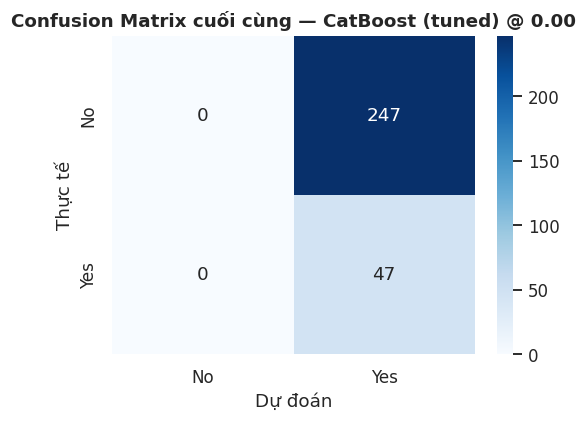

In [9]:
y_pred_tuned = (final_proba >= best_threshold).astype(int)
print(f"=== {winner_name} @ ngưỡng {best_threshold:.3f} ===")
print(classification_report(y_test, y_pred_tuned, target_names=['No', 'Yes']))

cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.title(f"Confusion Matrix cuối cùng — {winner_name} @ {best_threshold:.2f}")
plt.ylabel("Thực tế"); plt.xlabel("Dự đoán")
plt.tight_layout()
plt.savefig("../images/09_final_confusion_matrix.png", bbox_inches='tight')
plt.show()


## 6. Lưu mô hình cuối cùng

In [10]:
os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/final_model.pkl")
with open("../models/threshold.txt", "w") as f:
    f.write(str(best_threshold))
with open("../models/model_name.txt", "w") as f:
    f.write(winner_name)

eval_df.to_csv("../data/processed/day3_final_comparison.csv")

print("Đã lưu: final_model.pkl, threshold.txt, model_name.txt")


Đã lưu: final_model.pkl, threshold.txt, model_name.txt


## Tổng kết Ngày 3

- ✅ Tune sâu 2 ứng viên bằng RandomizedSearchCV + Pipeline (SMOTE đúng chuẩn trong mỗi fold)
- ✅ Đánh giá đầy đủ Precision/Recall/F1/PR-AUC/ROC-AUC trên tập test chưa từng bị đụng tới
- ✅ Chọn mô hình cuối cùng dựa trên số liệu, không suy đoán trước
- ✅ Tune ngưỡng quyết định theo đúng chi phí kinh doanh (ưu tiên Recall ≥ 0.80)
- ✅ Model, threshold đã lưu vào `models/`

**Bước tiếp theo (Ngày 4):** SHAP explainability → Streamlit dashboard → đóng gói & đẩy lên GitHub.
